# [Transformer](https://gaussian37.github.io/dl-concept-transformer/)
Pytorch에서는 `nn.TransformerEncoder`을 이용한 단일 컴포넌트를 이용하여 쉽게 Transformer 모델링을 할 수 있습니다.

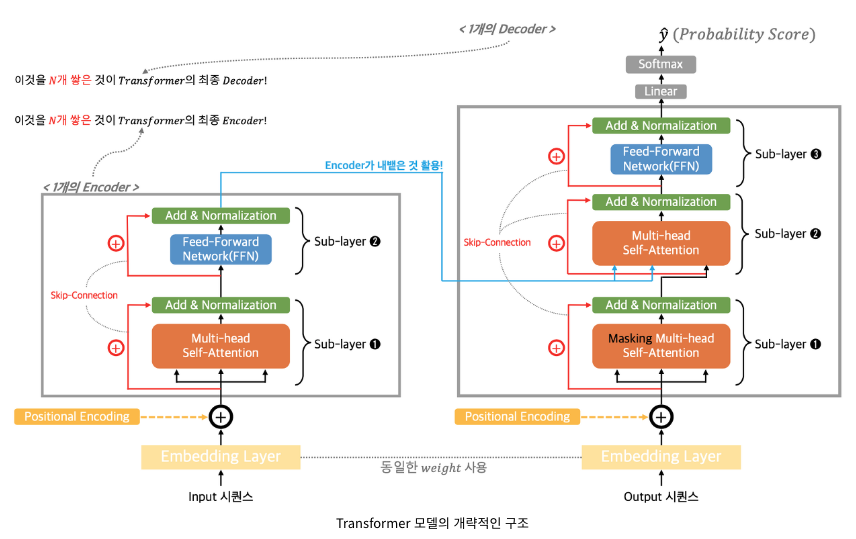

## Transformer와 Seq2Seq의 차이점

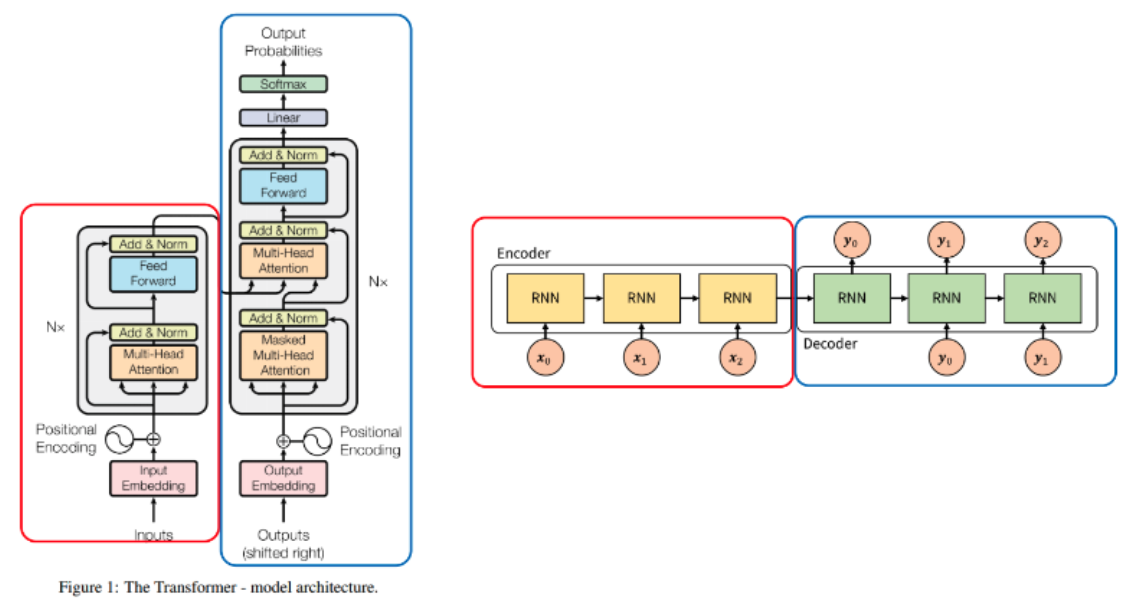

비슷한 점   
- `Seq2Seq`의 경우 Encoder(빨간색)와 Decoder(파란색) 형태로 이루어져 있고, 각 Encoder, Decoder에는 RNN을 사용하였습니다. 그리고 Encoder에서 Decoder로 정보를 전달할 때, 가운데 화살표인 context vector에 Encoder의 모든 정보를 저장하여 Decoder로 전달합니다.
- `Transformer`의 경우에도 Encoder(빨간색)와 Decoder(파란색) 형태가 있고 Encoder 끝단 부분에 Decoder로 전달되는 화살표가 있어서 Seq2Seq와 유사한 구조를 가집니다.
  
차이점
- 가장 큰 차이점은 `Seq2Seq`에서는 Encoder 연산이 끝난 후에 Decoder 연산이 시작된다면, `Transformer`는 Encoder와 Decoder가 같이 연산이 일어난다는 차이점이 있습니다.
- `Seq2Seq`에서는 Attention을 이용하기 때문에 RNN을 사용한다면, `Transformer`는 Self-Attention을 사용하기 때문에 RNN을 사용하지 않습니다.

## [Transformer 구조](https://glanceyes.com/entry/Transformer%EC%9D%98-Multi-Head-Attention%EA%B3%BC-Transformer%EC%97%90%EC%84%9C-%EC%93%B0%EC%9D%B8-%EB%8B%A4%EC%96%91%ED%95%9C-%EA%B8%B0%EB%B2%95#toc-link-1)

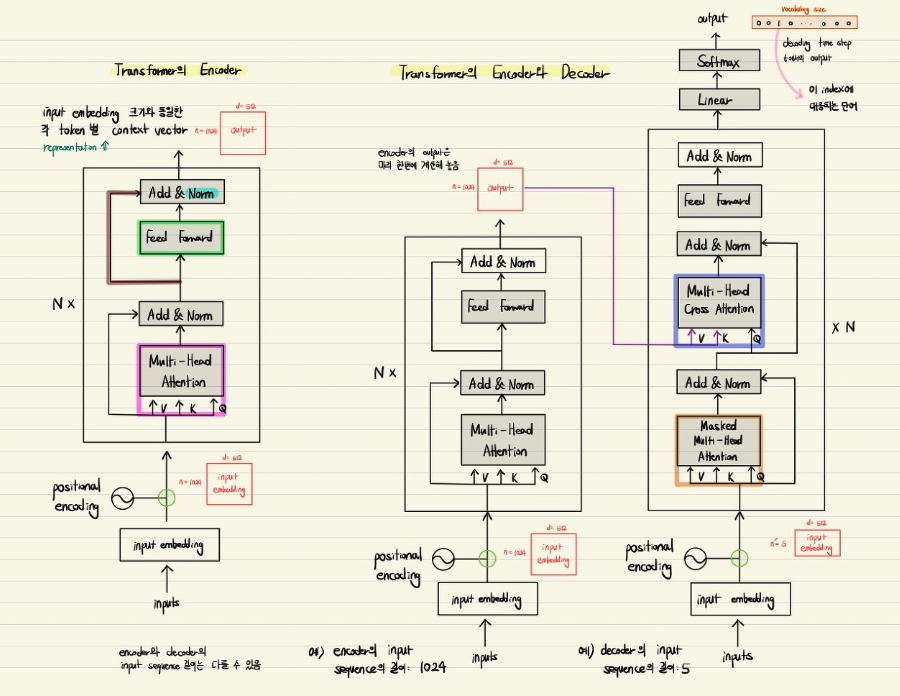

### Input, Output

- 입력
  - 각 단어는 One-hot Encoding 형태의 백터로 나타내어 집니다. 따라서 열벡터가 한 단어에 해당하며 열 벡터의 길이 즉, 행렬에서 행의 크기는 입력 단어의 가짓수와 관련이 있습니다.
  - 반면 열의 길이는 사용되는 sequence한 단어의 길이입니다. 문장에서 단어가 10개 있다면 행렬에서의 열 크기는 10이 된다고 볼 수 있습니다.

- 출력: 입력과 다르게 출력은 2가지의 Output이 표시되어 있습니다.
  - 위쪽에 있는 Output은 Transformer 모델을 통해 출력되는 실제 출력이고 아래쪽에 있는 Output은 Trnasformer에서 만들어낸 Output을 다시 입력으로 사용되는 것을 나타냅니다.
  - 다시 입력되는 Output의 첫 열벡터는 `<sos>`가 되고 X 표시가 되어있는 마지막 열벡터는 `<eos>`이므로 큰 의미는 없는 벡터입니다.
  - 따라서 shifted right라고 적힌 부분은 Output에서 하나씩 오른쪽으로 밀려서 다시 입력으로 들어가는 구조로 이해하시면 됩니다.

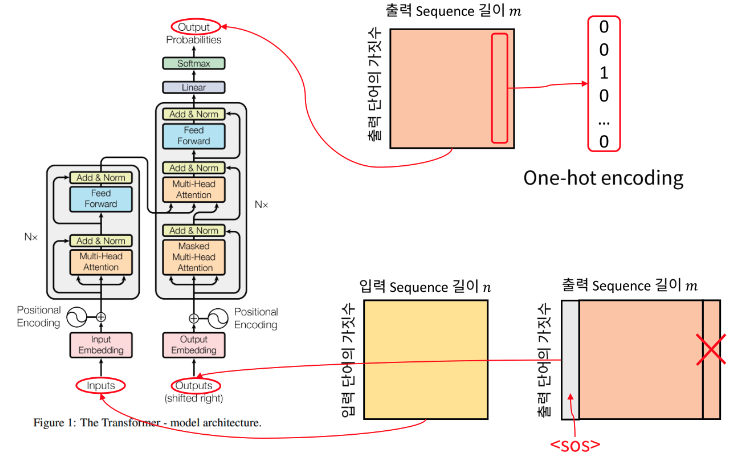

### Word Embedding

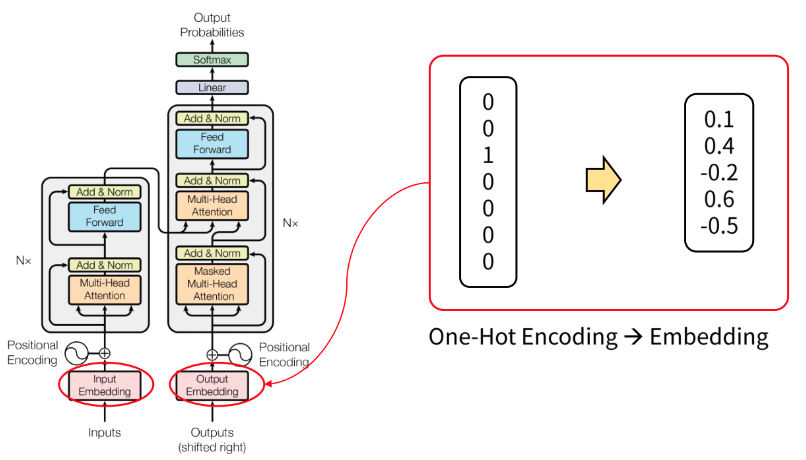

- 위 그림과 같이 one-hot encoding 벡터를 실수 형태로 변경하면 차원의 수를 줄일 수 있습니다.
- embedding의 경우 0을 기준으로 분포된 형태로 표현됩니다.

### [Positional Encoding](https://heekangpark.github.io/ml-shorts/positional-encoding-vs-positional-embedding)

#### RNN 제거

시퀀스 형태의 데이터는 각 항목의 값 뿐만 아니라 그 순서도 중요하다. "John loves Sarah"와 "Sarah loves John"은 단어는 모두 같지만 순서가 달라 의미가 다르다. 즉 시퀀스 형태의 데이터를 다루기 위해서는 순서 정보를 처리할 수 있는 모델을 사용해야 한다. RNN은 연속적으로 입력을 받아들이고 은닉 상태를 업데이트하기 때문에 시퀀스 형태의 데이터를 처리하기에 적합하다.    
  
하지만 RNN은 단점이 많은 구조이다.  
- 병렬화 문제: RNN은 그 구조상 순차적으로 입력을 처리해야 하기에 병렬화가 불가능하다. 이 때문에 대규모의 데이터셋을 이용한 학습이 불가능하다.(학습 시간이 너무 길어진다.)
- Long Distance Dependency 문제: 시퀀스에서 멀리 떨어진 항목들 간의 관계성은 `gradient vanishing/exploding` 문제로 학습이 잘 되지 않는다.

#### Positional Encoding 설명

RNN 구조에서는 순서 정보가 자연스럽게 모델에 입력됐지만, 어턴션 연산에서는 순서 정보가 고려되지 않는다. 그래서 트랜스포머 모델에서는 모델에 입력되는 입력 임베딩(input embedding)에 positional encoding이라 불리는, 입력 임베딩과 같은 차원의 위치 정보를 담고 있는 벡터를 더해준다.

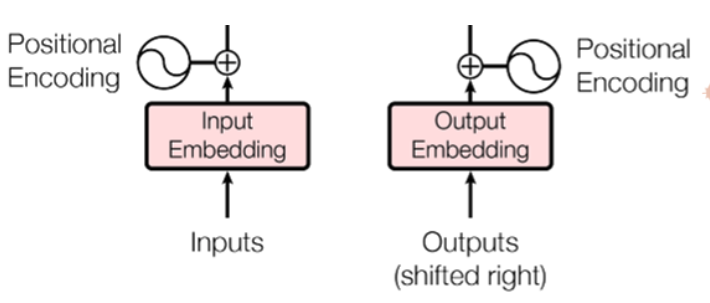

입력 임베딩의 차원이 $d$라 할 때, $p$번째 단어(token)의 positional encoding은 다음 식을 이용해 계산된다.  

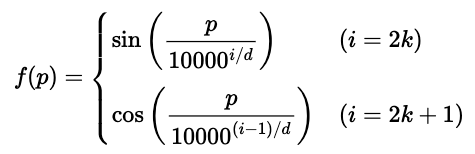

### [Self-Attention](https://techblog-history-younghunjo1.tistory.com/496)

`Transformer 모델`은 일반 `Attention`이 아닌 `Self-Attention` 기법을 사용합니다.

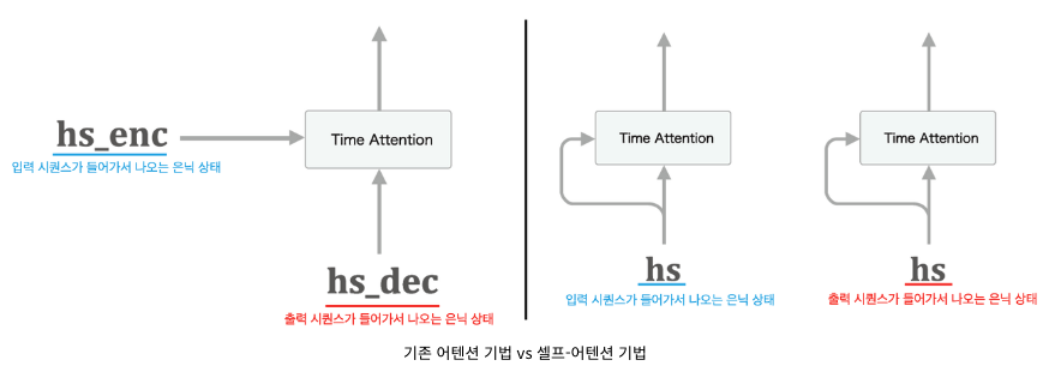

위의 이미지와 같이 기존 `Attention` 기법은 입력-출력 간에 대응되는 단어 관계를 파악하는 게 핵심이었다. 하지만 `Self-Attention` 기법은 입력, 출력 각 시퀀스 내부의 단어들 간의 대응 관계를 파악하는 것이 핵심이다. 아래 이미지처럼 기법의 차이가 난다.

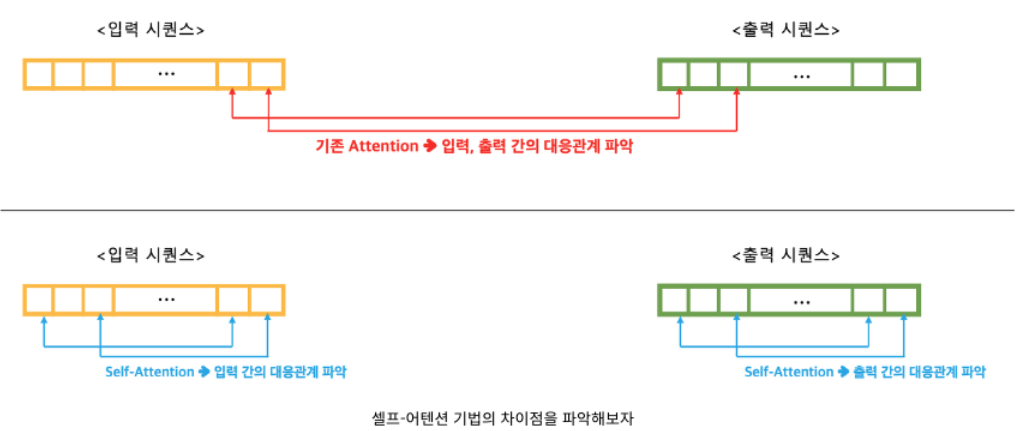

`Self-Attention` 기법은 입력 시퀀스 내에서의 대응관계를 학습하고 동시에 출력 시퀀스 내에서의 대응관계도 학습하는 방법이다.     
그리고 이러한 `Self-Attention` 기법을 사용해 만든 계층을 재귀적으로 쌓아서 기존 Seq2Seq2 모델의 RNN이 하던 (과거의 기억을 유지하는) 메모리 네트워크 역할을 대체하기도 한다.  

#### [Seq2Seq with Attention](https://glanceyes.tistory.com/entry/Attention-%EA%B8%B0%EB%B2%95%EC%9D%84-%EC%82%AC%EC%9A%A9%ED%95%9C-Seq2Seq-with-attention)

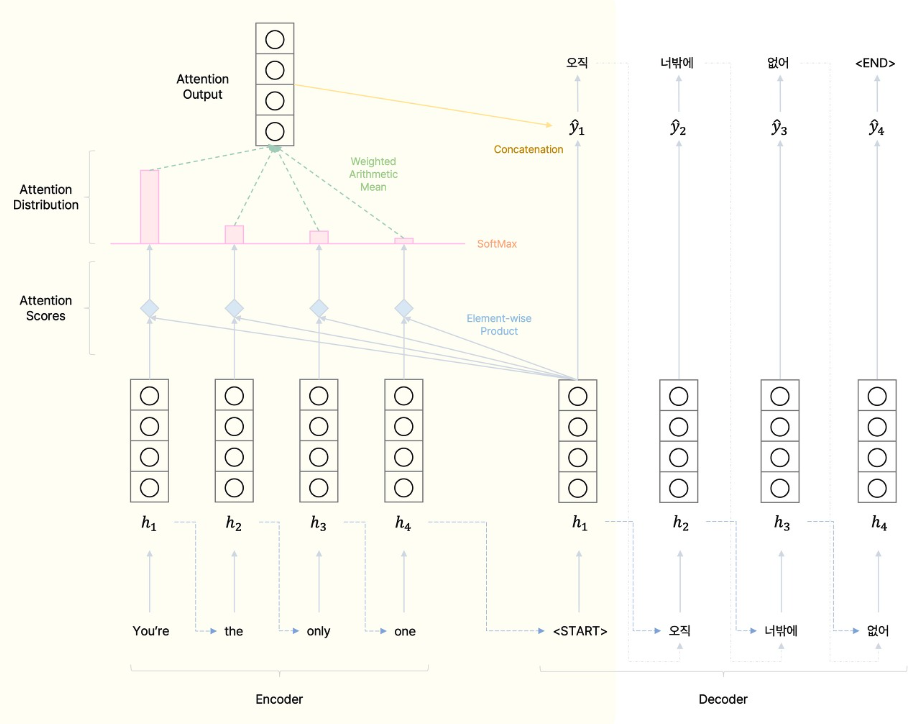

#### [self-attention의 학습과정](https://glanceyes.tistory.com/entry/Transformer%EC%9D%98-%ED%95%99%EC%8A%B5-%EA%B3%BC%EC%A0%95%EA%B3%BC-Seq2Seq-with-Attention-%EB%AA%A8%EB%8D%B8%EA%B3%BC%EC%9D%98-%EB%B9%84%EA%B5%90)

- 주어진 입력 벡터에 관해 어떠한 벡터를 중요하게 선별하여 반영할지에 관한 그 기준이 되는 벡터로 사용되는데, transformer에서는 여기서 각 단어에 대응되는 `query vector`를 만들어 사용한다.

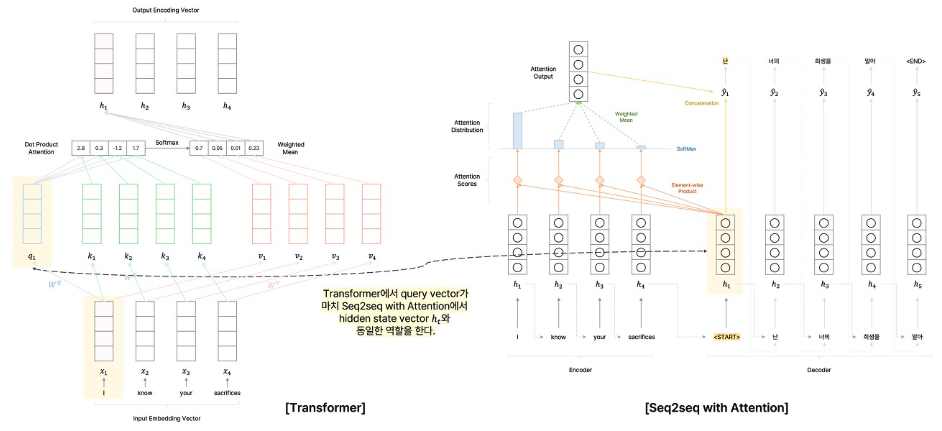

- 또한 attention 모듈에서 query vector와의 유사도를 구할 때 언급한 각 단어의 input vector를 그대로 사용하지 않고 각 단어마다 `key vector`라는 별개의 vector를 만들어 사용한다.

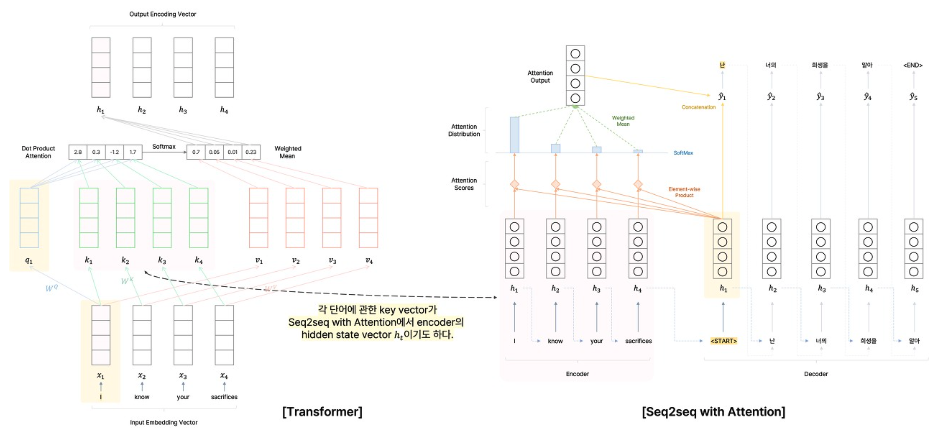

- Transformer에서는 Attention 모듈에서와는 달리 가중 평균을 구할 때 각 단어별로 임베딩된 input vector를 그대로 사용하지 않고 각 단어별 `value vector`를 사용한다.

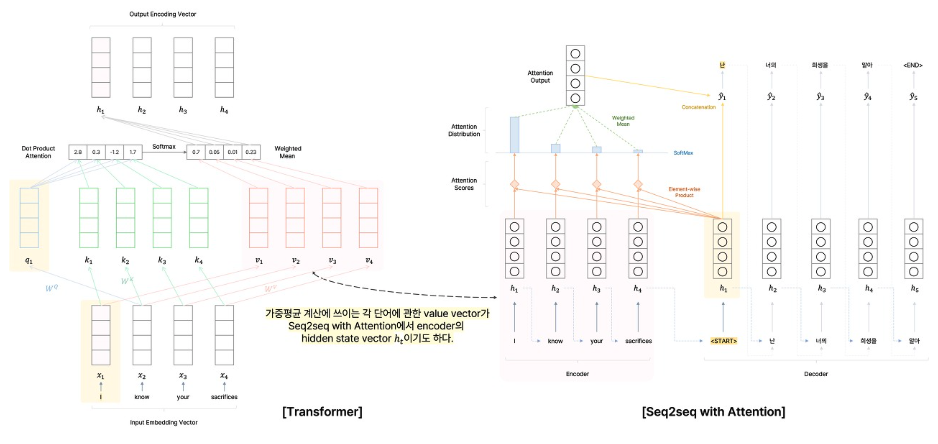

### [Multi-Head Attention](https://codingopera.tistory.com/44)

- 일반적인 Attention:    
예를 들어 [4x4] 크기의 문장 임베딩 벡터와 [4x8]의 Query, Key, Value가 있을 때, 일반적인 한 번에 계산하는 Attention 메커니즘은 [4x4]*[4x8]=[4x8]의 Attention Value가 한 번에 도출됩니다.

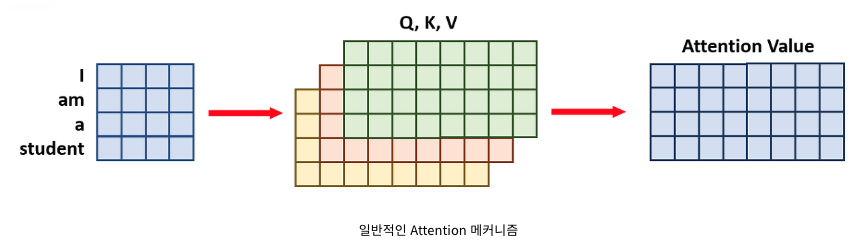

- Multi-head Attention:     
 - head의 수가 4개이므로 각 연산과정이 4분의 1만큼만 필요하다는 이야기입니다.
 - 때문에 위에서 크기가 [4x8]이었던 Query, Key, Value를 4 등분하여 [4x2]로 만듭니다.
 - 이렇게 되면 자연스럽게 각 Attention Value는 [4x2]가 됩니다.
 - 이 Attention Value들을 마지막에 concatenate를 시켜주면 위 그림과 같이 크기가 [4x8]이 되어 일반적인 Attention 메커니즘의 결괏값과 동일하게 됩니다.

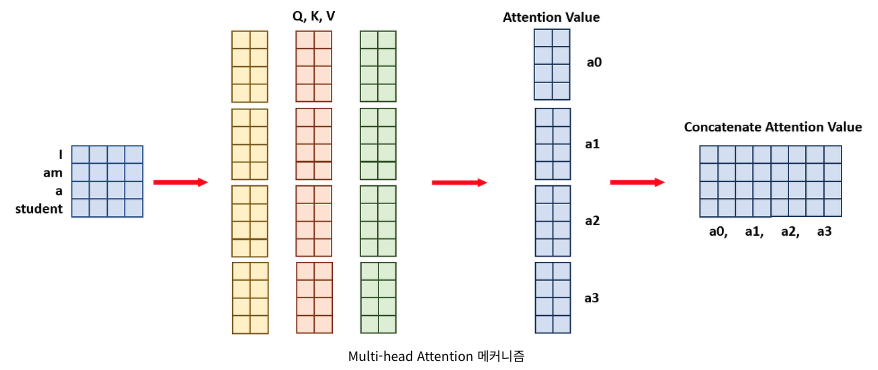

#### Multi-Head Attention 장점
- 어떤 동일한 sequence가 주어졌을 때도 특정한 query word에 관해 서로 다른 기준으로 여러 관점에서의 정보를 뽑아와야 할 필요성이 있다. 예를 들어, 문장에서 어떤 주어가 되는 대상이 한 행동 중심의 정보를 뽑아와야 할 뿐더러, 주체가 있는 장소에 관한 정보도 뽑아 올 필요가 있다.
- 그런데 기존의 One-Head Attention 기법은 어떤 한 단어가 다른 단어와 상호작용하는 정보를 한 가지 방법으로 뽑아올 수 밖에 없다. 그래서 head를 여러 개 두어서 좀 더 다양한 관점에서의 정보를 얻는 과정을 병렬적으로 수행하고자 하는 목적에서 Multi-Head Attention이 사용된다.

### [Masked Multi-Head Attention](https://glanceyes.com/entry/Transformer%EC%9D%98-Multi-Head-Attention%EA%B3%BC-Transformer%EC%97%90%EC%84%9C-%EC%93%B0%EC%9D%B8-%EB%8B%A4%EC%96%91%ED%95%9C-%EA%B8%B0%EB%B2%95#toc-link-20)

- Decoder에서 ground truth 문장의 각 단어에 관해 query, key, value vector를 만들어서 각 단어별 encoding vector를 만들고자 할 때, 앞에서 등장한 단어가 뒤에서 등장한 단어에 관해 가중치를 부여하여 파라미터 업데이트에 반영하는 경우가 과연 옳은 것인지를 고민해 볼 필요가 있다.
  - 예를 들어, token은 그 이후에 등장하는 단어 정보에 관해 인코딩된 벡터를 생성하게 되면 이는 결과적으로 앞 단어의 인코딩 벡터가 뒤의 단어의 정보도 반영하게 되는 현상이 발생한다.
- 이러한 문제 발생을 막고자 query와 key vector 간의 내적을 통해 attention score를 구한 후 해당 index 단어의 뒤에 등장하는 단어와의 attention score는 0으로 만들어서 후처리하는 것이 바로 Masked Multi-Head Attention의 핵심이다. 이는 앞에 등장하는 단어를 인코딩할 때 뒤에 등장하는 단어의 정보를 반영하지 못하도록 정보의 접근 권한을 차단하는 역할을 한다고 볼 수 있다.

요약하자면, masking은 self-attention 수행 시 행렬 Q와 K를 곱한 결과인 가중치 행렬에 적용하는데, 이는 self-attention 수행 시 앞 단어를 예측할 때 뒤쪽의 정보가 반영되는 것을 사전에 차단하기 위한 용도이다.

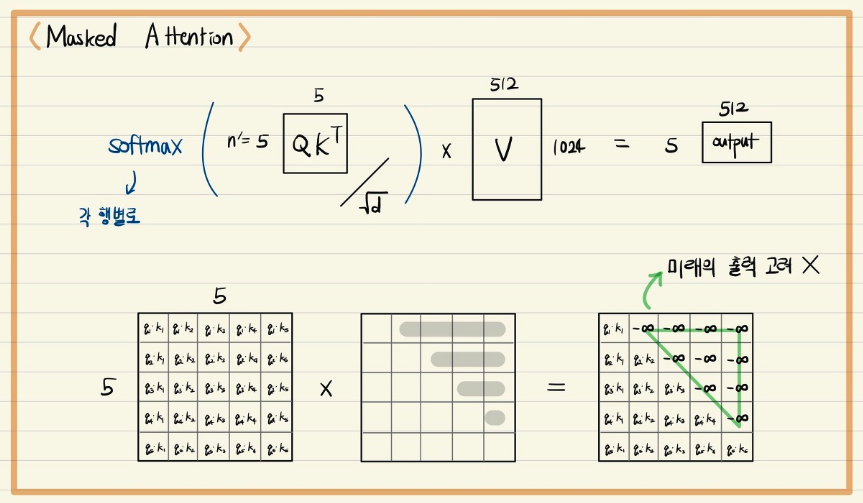

### [Multi-Head Cross Attention](https://glanceyes.com/entry/Transformer%EC%9D%98-Multi-Head-Attention%EA%B3%BC-Transformer%EC%97%90%EC%84%9C-%EC%93%B0%EC%9D%B8-%EB%8B%A4%EC%96%91%ED%95%9C-%EA%B8%B0%EB%B2%95#toc-link-21)

- 나아가 마찬가지로 Multi-Head Attention과 residual connection, layer normalization을 한 번 더 거치는데, 여기서는 encoder에서 각 단어별로 최종 인코딩된 벡터를 key와 value vector로 사용하고, query vector로는 decoder의 앞단에서 인코딩된 단어별 벡터를 사용한다.
- 이는 ground truth의 각 단어들이 encoder의 입력으로 주어지는 입력 문장에서 어떠한 단어에 더 주목할지를 구하고, ground truth 문장의 각 단어를 인코딩할 때 encoder의 입력 문장에서 어떠한 단어의 인코딩 벡터를 더 많이 반영할지를 가중 평균 구하는 것으로 해석할 수 있다.
- 마찬가지로 이를 Seq2Seq with Attention와 대응시켜면, decoder에서 각 단어에 해당되는 매 time step마다 hidden state를 가지고 encoder에서의 모든 hidden state와 attention score를 구한 후 가중 평균을 계산하여 decoder에서 해당 time step에서의 최종 인코딩된 hidden state vector를 구하는 과정으로 볼 수 있다.

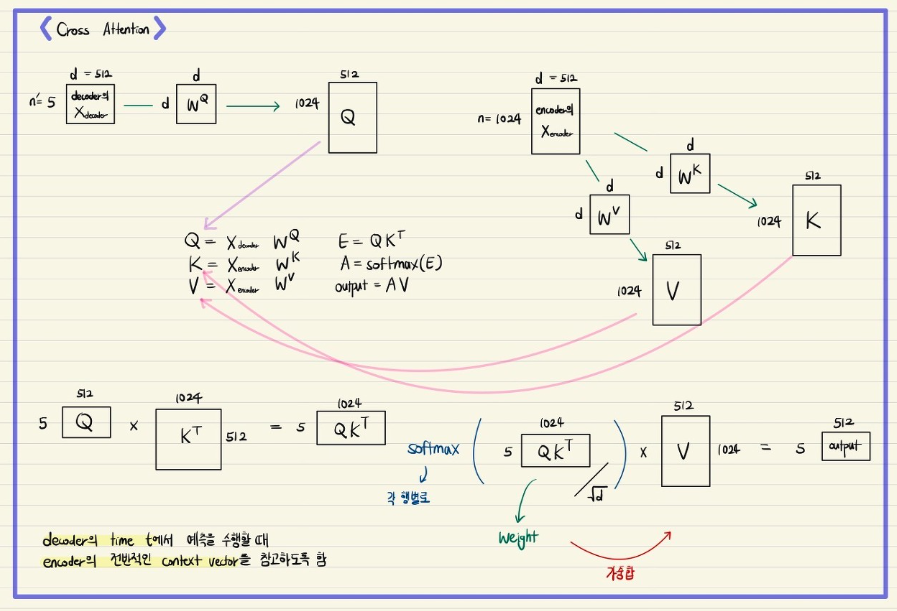

### Position-wise Feed-Forward Network(FFN)

Position wise Feed Forward는 단어의 Position 별로 Feed Forward 한다는 뜻입니다. 각 단어에 해당하는 열 벡터가 입력으로 들어갔을 때, `FC Layer -> Relu -> FC Layer` 연산을 거치게 됩니다.

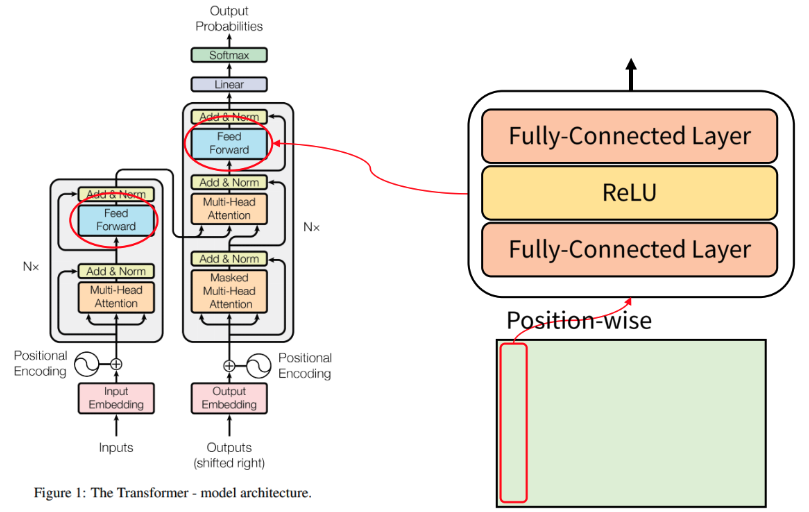

### Add, Norm

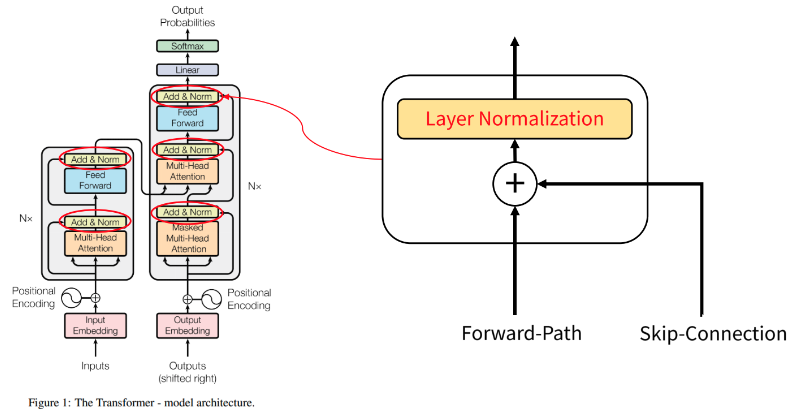

- [Skip Connection](https://techblog-history-younghunjo1.tistory.com/279)
  - Add는 Skip(Residual) Connection을 의미한다.  
  - Skip Connection을 사용하는 이유는 '덧셈' 연산의 역전파 시 기울기를 건드리지 않고 그대로 흘려보내는 특성 때문에 `기울기 소실, 폭발 문제를 막을 수 있기 때문이다.`
- Norm(Normalization)
  - 출력값들의 분포를 인위적으로 표준정규분포 형태로 만들어 주는 것이다.

### Output Softmax

- 마지막 Feed Forward를 통해 출력이 되면 Linear 연산을 통하여 출력 단어 종류 갯수로 출력 사이즈를 맞춰 줍니다.  
- 최종적으로 Softmax를 이용해 어떤 단어인지 Classification 문제를 해결할 수 있습니다.

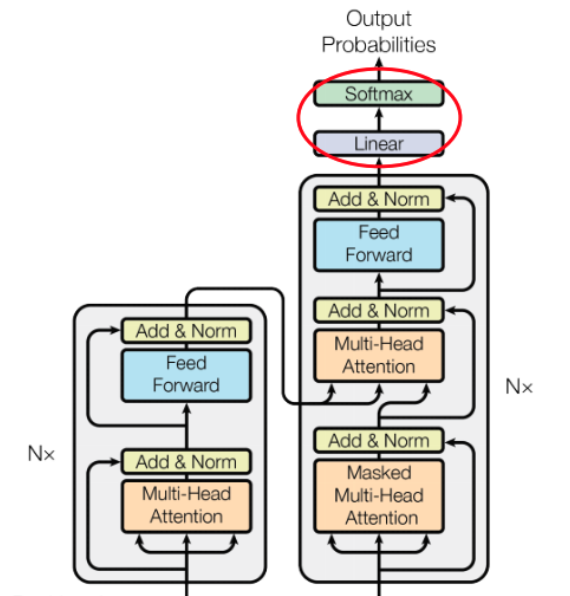

## [Transformer를 사용하는 것이 항상 좋을까?](https://glanceyes.com/entry/Transformer%EB%A5%BC-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94-%EA%B2%83%EC%9D%B4-%ED%95%AD%EC%83%81-%EC%A2%8B%EC%9D%84%EA%B9%8C)
- Transformer는 다양한 sequence data에 있어서 강점을 보이지만, self-attention을 수행하는 과정에서 다른 모델에 비해 상대적으로 많은 양의 데이터와 연산량을 요구한다.
- 그래서 어떠한 케이스에 상관없이 무조건적으로 Transformer를 택하여 사용하는 건 바람직하지 않을 수 있고, 사용자가 고려하는 목표와 주어진 환경을 종합적으로 고려할 필요가 있다.

### Transformer 사용을 피해야 하는 경우
- Feature를 가지고 하나의 Sequence로 만드는 것이 어려운 경우
  - 예를 들어, 주어진 데이터의 feature의 순서가 중요하지 않아서 이를 하나의 sequence로 묶기 어려운 경우가 존재한다.
  - 이때 feature 사이에 관계를 찾는 것이 어려워서 Transformer의 입력 데이터를 어떻게 만들어서 주는 것이 효율적인지 답을 찾기 힘들 수 있다.
- Feature와 Label의 수가 데이터에 비해 너무 많은 경우
  - 또한 feature의 수와 예측해야 하는 label의 수가 너무 많은 데 반해 학습으로 주어지는 데이터의 양이 많지 않으면 Transformer가 오히려 더 불리할 수 있다.
- Sequence 길이가 너무 긴 경우
  - Sequence의 길이가 길어지면 Transformer의 Self-attention을 사용하는 과정에서 데이터의 양이 증가함에 따라 시간복잡도(time complexity)가 증가한다는 단점이 있다.

### [Transformer를 사용하지 않은 경진대회](https://www.kaggle.com/c/lish-moa/discussion/202256)
MoA는 약물을 투여했을 때 데이터의 여러 특징에 따라 200여 개의 화학 반응 중 어떤 반응이 나타날지를 예측하는 task를 수행해야 하는데, 다음과 같은 한계로 인해 Transformer가 제대로 작동하지 않았다고 한다.


- 주어진 데이터를 Sequence로 묶기가 어렵다.
  - 학습 데이터에서 사람에게 투여한 약물에 관한 정보와 그 약을 투여 받은 사람의 정보를 같이 학습하는데, 이 둘 사이의 정보는 사실상 연관관계가 없다. 앞서 설명한 분자의 예시에서는 분자를 구성하는 임의의 두 원자 각각의 정보와 두 원자가 어떻게 결합했는지에 관한 정보는 서로 연관되어 분자를 대표한다고 볼 수 있지만, 이 대회에서는 약물 정보와 약물을 투여 받은 사람의 정보를 연관짓기에는 어려움이 존재한다.
- Feature의 수가 너무 많다.
  - 학습할 데이터의 feature 수가 875개에 달하는데, 이는 약 24,000개의 데이터에 비해 데이터를 표현하는 feature의 수가 너무 많아 과적합 문제를 발생할 가능성이 있다.
- 데이터에 비해 예측해야 할 클래스가 많다.
  - 어떤 반응이 나타나는지를 예측해야 하는 클래스 수가 207개였는데, 이 또한 클래스를 매우 세분화하여 예측해야 하므로 학습이 제대로 되지 않거나 또는 과적합이 이루어질 가능성이 있다.

그래서 이 대회에서 좋은 성적을 보인 아래의 solution에서는 1D-CNN을 사용하는 방법을 택했다.

# Transformer Layers

## nn.TransformerEncoderLayer
- d_model: 기본값이 512
- nhead: 기본값이 8
- dim_feedforward: 기본값이 2048
- batch_first: 기본값이 False

## nn.TransformerEncoder
- encoder_layer: TransformerEncoderLayer의 객체
- num_layers: 인수로 전달 받은 인코더 레이어를 얼마나 쌓을 것인가의 수

## [nn.Transformer](https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html#transformer)
트랜스포머 모델의 주요 파라메터는 다음과 같습니다.
- `d_model`: 트랜스포머의 인코더와 디코더에서의 정해진 입력과 출력의 크기를 의미합니다. (default=512)
- `num_encoder_layers`: 트랜스포머 모델에서 인코더가 총 몇 층으로 구성되었는지를 의미합니다. (default=6)
- `num_decoder_layers`: 트랜스포머 모델에서 디코더가 총 몇 층으로 구성되었는지를 의미합니다. (default=6)
- `nhead`: 멀티헤드 어텐션 모델의 헤드 수, 어텐션을 사용할 때 여러 개로 분할해서 병렬로 어텐션을 수행하고 결과값을 다시 하나로 합치는 방식에서 병렬의 수 (default=8)
- `dim_feedforward`: feedforward network model 의 차원, 피드 포워드 신경망의 은닉층의 크기(default=2048).

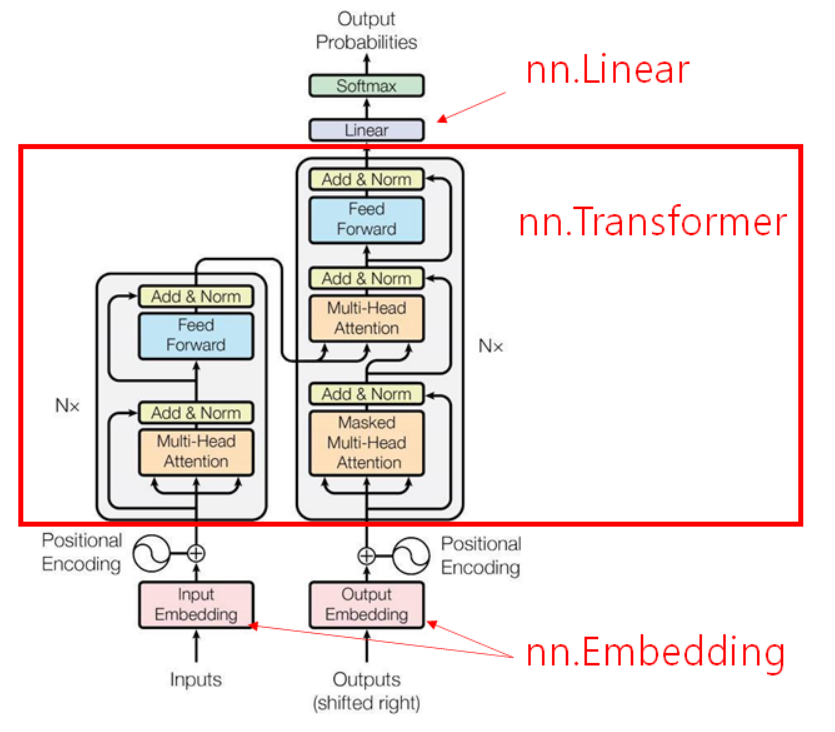

# 초기 설정

In [2]:
!pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 16.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.8/30.8 MB 58.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kiwipiepy-model: filename=kiwipiepy_model-0.16.0-py3-none-any.whl size=30813255 sha256=b8d4976a69e3bad71049d0ea46c6c4743dab17dd6cb25fcf69793cbedbb79bf7
  Stored in directory: /root/.cache/pip/wheels/6b/03/2b/ac2c97cc65ebd9df3516f4b900adc2f0a744df8d1375b2e2ef
Successfully built kiwipiepy-model


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import torch
from tqdm.auto import tqdm
import random
import os

In [5]:
def reset_seeds(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

In [6]:
DATA_PATH = "/content/drive/MyDrive/google_lecture/06. deep learning/3. NLP Pytorch/data/"
SEED = 42

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# 예제 - 분류문제

## Data

In [37]:
df_ko = pd.read_csv(DATA_PATH+"naver_review/naver_review_train.csv", sep="\t")

df_ko = df_ko[:10000]
print(f'{df_ko.isnull().sum().sum()} / {df_ko.shape}')
df_ko.head()

0 / (10000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


## Text Preprocessing

### Cleaning

In [9]:
df_ko['document'] = df_ko['document'].map(lambda x: x.strip()) # 문자열의 앞뒤 공백 제거
df_ko['document'] = df_ko['document'].map(lambda x: x.replace("..", " "))

print(f'{df_ko.isnull().sum().sum()} / {df_ko.shape}')
df_ko.head()

0 / (10000, 3)


,id,document,label
0,9976970,아 더빙 진짜 짜증나네요 목소리,0
1,3819312,흠 .포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 솔직히 재미는 없다 평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


### 토큰화 & 어휘집

In [10]:
!pip install kiwipiepy

In [11]:
from kiwipiepy import Kiwi
from kiwipiepy.utils import Stopwords

stopwords =  Stopwords() # 불용어
kiwi = Kiwi() # 형태소 분석기

In [12]:
def tokenizer(text):
    tokens = kiwi.tokenize(text, stopwords=stopwords) # 토큰화
    return [ t.form for t in tokens if t.tag[0] in "NJMV" ] # N:명사, J:조사, M:관형사/부사, V: 동사

In [13]:
def yield_tokens(data, tokenizer):
    for text in tqdm(data):
        yield tokenizer(text)

In [15]:
from torchtext.vocab import build_vocab_from_iterator

gen = yield_tokens(df_ko["document"],tokenizer) # 토큰화
vocab = build_vocab_from_iterator(gen, specials=["<pad>","<unk>"]) # 어휘집
vocab.set_default_index(vocab["<unk>"])

len(vocab)

  0%|          | 0/10000 [00:00<?, ?it/s]

10738

In [16]:
features = [ vocab(tokenizer(text)) for text in tqdm(df_ko["document"].tolist()) ]

len(features)

  0%|          | 0/10000 [00:00<?, ?it/s]

10000

### 패딩

In [17]:
max_len = max(len(lst) for lst in features)
max_len

48

In [18]:
features = [ lst + [0] * (max_len - len(lst))  if len(lst) < max_len else lst for lst in tqdm(features) ]

features = np.array(features)
features.shape

  0%|          | 0/10000 [00:00<?, ?it/s]

(10000, 48)

In [19]:
target = df_ko["label"].to_numpy().reshape(-1,1)
target.shape

(10000, 1)

## Dataset

In [20]:
from torch.utils.data import Dataset

In [21]:
class ReviewDataset(Dataset):
    def __init__(self,features,target=None):
        super().__init__()
        self.features = features # features
        self.target = target # target

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self,idx):
        item = {}
        item["x"] = torch.LongTensor(self.features[idx])
        if self.target is not None:
            item["y"] = torch.Tensor(self.target[idx])
        return item

In [23]:
dt = ReviewDataset(features,target)
len(dt)

10000

In [24]:
dt[0]

{'x': tensor([524,  11, 131,  10, 632,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0]),
 'y': tensor([0.])}

## DataLoader

In [25]:
from torch.utils.data import DataLoader

In [26]:
dl = DataLoader(dt,batch_size=2)
batch = next(iter(dl))
batch

{'x': tensor([[ 524,   11,  131,   10,  632,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
         [ 271,  573,  505,    2,   54, 1524,   15,  645,  539,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0]]),
 'y': tensor([[0.],
         [1.]])}

## Model

In [27]:
emb = torch.nn.Embedding(len(vocab),512)
x = emb(batch["x"])
x.shape

torch.Size([2, 48, 512])

In [28]:
enc_layer = torch.nn.TransformerEncoderLayer(512,8,batch_first=True)
encoder = torch.nn.TransformerEncoder(enc_layer,2)
encoder(x).shape

torch.Size([2, 48, 512])

In [29]:
class Net(torch.nn.Module):
    def __init__(self,vocab_size,max_len,d_model=32,nhead=4,dim_feedforward=64,num_layers=1,device="cpu"):
        super().__init__()
        self.pos = torch.arange(max_len).to(device)
        self.pos_emb_layer = torch.nn.Embedding(max_len, d_model)

        self.emb_layer = torch.nn.Embedding(vocab_size, d_model)
        self.enc_layer = torch.nn.TransformerEncoderLayer(d_model,nhead,dim_feedforward,batch_first=True)
        self.encoder = torch.nn.TransformerEncoder(self.enc_layer,num_layers)
        self.flatten = torch.nn.Flatten()
        self.dropout = torch.nn.Dropout(0.5)
        self.output_layer = torch.nn.Linear(max_len*d_model ,1)
    def forward(self,x):
        pos = self.pos_emb_layer(self.pos) # s , f
        x = self.emb_layer(x) # b, s ,f
        x = torch.add(x,pos) # b ,s ,f

        x = self.encoder(x) # b, s, f
        x = self.flatten(x) # b , sxf (2차원 형태)
        x = self.dropout(x)
        return self.output_layer(x)

In [30]:
model = Net(len(vocab), max_len)
pred = model(batch["x"])
pred.shape

torch.Size([2, 1])

## Engine

In [31]:
def train_loop(dataloader,model,loss_fn,optimizer,device):
    epoch_loss = 0
    model.train() # 모델 객체를 학습모드로 전환
    for batch in dataloader:
        pred = model( batch["x"].to(device) )
        loss = loss_fn( pred,batch["y"].to(device) )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(dataloader)

    return epoch_loss

In [32]:
@torch.no_grad()
def test_loop(dataloader,model,loss_fn,device):
    model.eval() # 평가 모드
    sig = torch.nn.Sigmoid()
    pred_list = []
    epoch_loss = 0
    for batch in dataloader:
        pred = model(batch["x"].to(device))

        # 검증 평가할 경우
        if batch.get("y") is not None:
            loss = loss_fn(pred,batch["y"].to(device))
            epoch_loss += loss.item()

        # 예측값 만들기
        pred = sig(pred)
        pred = pred.to("cpu").numpy()
        pred_list.append(pred)

    pred = np.concatenate(pred_list)
    epoch_loss /= len(dataloader)
    return epoch_loss, pred

## Training

In [33]:
batch_size = 32
loss_fn = torch.nn.BCEWithLogitsLoss() # 손실 객체
epochs = 100
n_splits = 5 # 폴드수
model_hp = {
    "vocab_size": len(vocab),
    "max_len": max_len,
    "d_model": 32,
    "nhead" : 8,
    "dim_feedforward" : 64,
    "num_layers": 1,
    "device" : device
}

In [34]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
cv = KFold(n_splits=n_splits,shuffle=True, random_state=SEED)

In [35]:
is_holdout = False
reset_seeds(SEED)
best_score_list = []
for i,(tri,vai) in enumerate(cv.split(features)):

    model = Net(**model_hp).to(device)
    optimizer = torch.optim.Adam(model.parameters())

    train_dt = ReviewDataset(features[tri],target[tri])
    valid_dt = ReviewDataset(features[vai],target[vai])
    train_dl = torch.utils.data.DataLoader(train_dt, batch_size=batch_size, shuffle=True)
    valid_dl = torch.utils.data.DataLoader(valid_dt, batch_size=batch_size,shuffle=False)

    best_score = 0
    patience = 0

    for epoch in tqdm(range(epochs)):

        train_loss = train_loop(train_dl, model, loss_fn,optimizer,device )
        valid_loss , pred = test_loop(valid_dl, model, loss_fn,device  )
        pred = np.where(pred>0.5,1,0)

        score = accuracy_score(target[vai],pred)
        print(train_loss,valid_loss, score)
        patience += 1
        if best_score < score:
            patience = 0
            best_score = score
            torch.save(model.state_dict(),f"model_{i}.pth")

        if patience == 5:
            break
    print(f"Fold ({i}), BEST ACC: {best_score}")
    best_score_list.append(best_score)

    if is_holdout:
        break

  0%|          | 0/100 [00:00<?, ?it/s]

0.7323281157016754 0.6872022218174405 0.5485
0.6569887782335282 0.6190626640168447 0.6525
0.5733250942230225 0.5721203268520416 0.711
0.5047236660718918 0.5735043878593142 0.701
0.4501867320537567 0.550415955838703 0.7225
0.3995710759758949 0.592839072621058 0.724
0.3540253641307354 0.6390396522151099 0.7025
0.31190065428614616 0.6407039851423294 0.7195
0.2686531806141138 0.7411355030915093 0.718
0.22799123647809028 0.7134970975300622 0.707
0.20168062995374203 0.8824006030483852 0.7195
Fold (0), BEST ACC: 0.724


  0%|          | 0/100 [00:00<?, ?it/s]

0.7399140594005584 0.7343547826721555 0.498
0.7009176003932953 0.6742499196340167 0.5565
0.6236165708303452 0.5935961140526665 0.6555
0.5477489581108094 0.5697095730001964 0.697
0.489518151640892 0.5895786294861446 0.693
0.435362405538559 0.5586021462130168 0.731
0.40145299351215363 0.6246378544777159 0.709
0.33906213200092317 0.5876701374848684 0.7285
0.29957361094653606 0.7277466659508054 0.6855
0.25980044807493685 0.7051697538958656 0.7305
0.22218819028139114 0.7106170576243174 0.7365
0.19717625233530997 0.8258868796484811 0.729
0.169391678981483 1.0006662768030923 0.721
0.14683533572033047 0.9235724035709624 0.7315
0.1264835785701871 1.0218357722910623 0.728
0.11110891648381949 1.1247345024631137 0.7195
Fold (1), BEST ACC: 0.7365


  0%|          | 0/100 [00:00<?, ?it/s]

0.7373101615905762 0.709316282991379 0.493
0.6925784451961517 0.6197518266382671 0.6565
0.5982577178478241 0.5635552732717424 0.698
0.5200729283094406 0.6480297479364607 0.677
0.46500564604997635 0.5667769063323264 0.7135
0.40924949425458906 0.5703611287569242 0.726
0.36756750667095184 0.5693236702964419 0.7355
0.3324089334011078 0.5711696060403945 0.739
0.2884643948376179 0.5873882191048728 0.737
0.2524674705564976 0.6976960762034333 0.7305
0.22097521913051604 0.7058548496829139 0.7395
0.19051698656380175 0.7368558499784696 0.734
0.16434484066069127 0.8419335971749018 0.7415
0.14827570748329164 0.9881004918780592 0.7295
0.12554533246532082 0.9994831636311516 0.7255
0.11308637333288789 1.08805092784857 0.73
0.10010046203248203 1.3687499265467364 0.728
0.08770234182849526 1.3755514896105205 0.7285
Fold (2), BEST ACC: 0.7415


  0%|          | 0/100 [00:00<?, ?it/s]

0.7318980922698974 0.681808350578187 0.5455
0.6550254645347595 0.609270365465255 0.6555
0.5756323821544648 0.5585800220095922 0.707
0.5063008881807327 0.5887150934764317 0.7
0.468979090154171 0.5948515293144044 0.7105
0.4122446559071541 0.5869030058383942 0.726
0.3746333757042885 0.6059486260489811 0.7325
0.3391527743637562 0.6098600696949732 0.7395
0.29731889951229096 0.6235224098440201 0.746
0.2628008328974247 0.6688313569341388 0.741
0.22988433384895324 0.6867426543954819 0.741
0.2011115896999836 0.7674133030195085 0.7375
0.17456847949326038 0.909388845402097 0.732
0.15967737020552158 1.0304817647214919 0.7245
Fold (3), BEST ACC: 0.746


  0%|          | 0/100 [00:00<?, ?it/s]

0.7455211093425751 0.6759899476217845 0.592
0.6629847880601883 0.6198187191334982 0.641
0.5757798546552658 0.5602729050886064 0.703
0.5119729760885239 0.5472469741389865 0.7235
0.4600169360041618 0.5397455753788115 0.7355
0.40616004490852353 0.5643383134452123 0.7335
0.3616333975791931 0.5750090848831904 0.727
0.3179601112604141 0.6244805644428919 0.7315
0.2806792970448732 0.6332115729649862 0.7435
0.2482096557766199 0.6631401247448392 0.7365
0.21430942597985267 0.7513326113186185 0.7315
0.1837942487746477 0.8291591415329586 0.736
0.161277420014143 0.8880826196973286 0.736
0.14300624726712705 1.0041705540248327 0.7345
Fold (4), BEST ACC: 0.7435


# 예제 - 번역

## Data

In [40]:
train = pd.read_csv(f"{DATA_PATH}translate_en_ko.csv")
train.shape

(5794, 2)

## Text Preprocessing

### Cleaning

In [41]:
train["en"] = train["en"].str.replace("[^a-zA-Z0-9 .,!?\'\"]" , "",regex=True).str.lower()
train["ko"] = train["ko"].str.replace("[^가-힣0-9 .,!?\'\"]" , "",regex=True)

### 토근화 & 어휘집

#### 한국어

In [42]:
!pip install kiwipiepy

In [43]:
from kiwipiepy import Kiwi
from kiwipiepy.utils import Stopwords

stopwords =  Stopwords() # 불용어
kiwi = Kiwi() # 형태소 분석기

In [44]:
def tokenizer(text):
    tokens = kiwi.tokenize(text, stopwords=stopwords) # 토큰화
    return [ t.form for t in tokens if t.tag[0] in "NJMV" ] # N:명사, J:조사, M:관형사/부사, V: 동사

In [45]:
def yield_tokens(data, tokenizer):
    for text in tqdm(data):
        yield tokenizer(text)

In [46]:
from torchtext.vocab import build_vocab_from_iterator

gen = yield_tokens(train["ko"],tokenizer) # 토큰화
vocab_ko = build_vocab_from_iterator(gen, specials=["<pad>","<unk>"]) # 어휘집
vocab_ko.set_default_index(vocab_ko["<unk>"])
len(vocab_ko)

  0%|          | 0/5794 [00:00<?, ?it/s]

2962

In [47]:
src_data = [ vocab_ko(tokenizer(text)) for text in train["ko"].tolist() ]

#### 영어

In [48]:
from torchtext.data.utils import get_tokenizer
tokenizer = get_tokenizer("basic_english")

In [49]:
tgt_data = []
for text in train["en"]:
    t_list = ["<sos>"] + tokenizer(text) + ["<eos>"]
    tgt_data.append(t_list)

In [50]:
vocab_en = build_vocab_from_iterator(tgt_data,specials=["<pad>","<unk>","<sos>","<eos>"])
vocab_en.set_default_index(vocab_en["<unk>"])
len(vocab_en)

3129

In [51]:
tgt_data = [ vocab_en(lst) for lst in tgt_data ]

## Dataset

In [52]:
from torch.utils.data import Dataset

In [53]:
class TranslateDataset(torch.utils.data.Dataset):
    def __init__(self,src,tgt):
        self.src = src
        self.tgt = tgt
    def __len__(self):
        return len(self.src)
    def __getitem__(self,idx):
        item = {}
        item["src"] = torch.LongTensor(self.src[idx])
        item["tgt"] = torch.LongTensor(self.tgt[idx])
        return item

In [54]:
dt = TranslateDataset(src_data,tgt_data)
dt[0]

{'src': tensor([2652, 2870]),
 'tgt': tensor([   2,  210, 2696,   29,   27,   11,  291, 1584,    4,    3])}

### collate_fn

In [55]:
def collate_fn(lst):
    src= [ item["src"] for item in lst ]
    tgt= [ item["tgt"] for item in lst ]
    src = torch.nn.utils.rnn.pad_sequence(src,batch_first=True)
    tgt = torch.nn.utils.rnn.pad_sequence(tgt,batch_first=True)
    return {"src": src, "tgt": tgt}

## DataLoader

In [56]:
from torch.utils.data import DataLoader

In [57]:
dl = DataLoader(dt,batch_size=2,collate_fn=collate_fn)
batch = next(iter(dl))
batch

{'src': tensor([[2652, 2870],
         [ 939, 1070]]),
 'tgt': tensor([[   2,  210, 2696,   29,   27,   11,  291, 1584,    4,    3],
         [   2,   11,  574,   23, 1314,    4,    3,    0,    0,    0]])}

## Model

### nn.Transformer

In [58]:
transformer = torch.nn.Transformer(batch_first=True)
transformer

Transformer(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, o

- forward 주요 파라미터
    - src : 인코더의 입력 텐서
    - tgt : 디코더의 입력 텐서
    - tgt_mask : 예측시점의 어텐션 방지를 위한 tgt 시퀀스에 대한 마스크

In [59]:
d_model = 512
src_emb = torch.nn.Embedding(len(vocab_ko), d_model )
tgt_emb = torch.nn.Embedding(len(vocab_en), d_model )

src = src_emb(batch["src"])
tgt = tgt_emb(batch["tgt"])
src.shape , tgt.shape

(torch.Size([2, 2, 512]), torch.Size([2, 10, 512]))

In [60]:
tgt_mask = torch.nn.Transformer.generate_square_subsequent_mask(tgt.shape[1])
tgt_mask

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [61]:
output = transformer(src,tgt , tgt_mask = tgt_mask)
output.shape

torch.Size([2, 10, 512])

### PositionalEncoding
$$
PE_{(pos,\ 2i)}=sin(pos/10000^{2i/d_{model}})
$$

$$
PE_{(pos,\ 2i+1)}=cos(pos/10000^{2i/d_{model}})
$$

In [62]:
class PositionalEncoding(torch.nn.Module):
    def __init__(self,max_len,d_model):
        super().__init__()
        pos_encoding = torch.zeros(max_len,d_model) # seq, feature
        pos = torch.arange(0,max_len,dtype=torch.float32).view(-1,1)
        _2i= torch.arange(0,d_model,step=2,dtype=torch.float32)

        pos_encoding[:,0::2] = torch.sin(pos / 10000 ** (_2i/d_model))
        pos_encoding[:,1::2] = torch.cos(pos / 10000 ** (_2i/d_model))
        # pos_encoding -> (max_len, d_model)
        pos_encoding = pos_encoding.unsqueeze(0) # (batch, max_len, d_model)

        self.register_buffer("pos_encoding",pos_encoding)
    def forward(self,x):
        return x + self.pos_encoding[:,:x.shape[1]]

In [63]:
src.shape

torch.Size([2, 2, 512])

In [64]:
pe = PositionalEncoding(1000,512)
pe(src).shape

torch.Size([2, 2, 512])

### Seq2Seq

In [65]:
class Net(torch.nn.Module):
    def __init__(self,
                 src_vocab_size,
                 tgt_vocab_size,
                 max_len=1000,
                 d_model = 512,
                 nhead=8,
                 num_encoder_layers=6,
                 num_decoder_layers=6,
                 dim_feedforward=2048):

        super().__init__()
        self.src_emb = torch.nn.Embedding(src_vocab_size,d_model)
        self.tgt_emb = torch.nn.Embedding(tgt_vocab_size,d_model)

        self.pe = PositionalEncoding(max_len,d_model)

        self.transformer = torch.nn.Transformer(d_model=d_model,
                                                nhead=nhead,
                                                num_encoder_layers=num_encoder_layers,
                                                num_decoder_layers=num_decoder_layers,
                                                dim_feedforward=dim_feedforward,
                                                batch_first=True)
        self.fc_layer = torch.nn.Linear(d_model,tgt_vocab_size)

    def forward(self,src,tgt,tgt_mask):
        src = self.pe( self.src_emb(src) )
        tgt = self.pe( self.tgt_emb(tgt) )
        x = self.transformer(src,tgt,tgt_mask=tgt_mask) # batch,seq,d_model
        return self.fc_layer(x) # batch,seq,단어별 예측값

    # 실제 예측시 사용할 메서드
    def ecoder(self,src):
        src = self.pe( self.src_emb(src) )
        return self.transformer.encoder(src)

    def decoder(self,tgt,memory):
        tgt = self.pe( self.tgt_emb(tgt) )
        x = self.transformer.decoder(tgt,memory=memory)
        return self.fc_layer(x)

In [66]:
tgt_mask = torch.nn.Transformer.generate_square_subsequent_mask(batch["tgt"].shape[1])
tgt_mask

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [67]:
model = Net(len(vocab_ko), len(vocab_en))
pred = model(batch["src"],batch["tgt"],tgt_mask)
pred.shape

torch.Size([2, 10, 3129])

In [68]:
src = batch["src"][:1]
src # bathc, seq

tensor([[2652, 2870]])

In [69]:
tgt = batch["tgt"][:1,:1]
tgt # batch , seq

tensor([[2]])

In [70]:
model.eval()
memory = model.ecoder(src)
pred = model.decoder(tgt,memory)
pred.shape

torch.Size([1, 1, 3129])

In [71]:
pred[-1,-1].argmax()

tensor(1039)

In [72]:
vocab_en.lookup_token(1974)

'charity'

## Engine

In [88]:
class EarlyStopper(object):

    def __init__(self, num_trials, save_path):
        self.num_trials = num_trials
        self.trial_counter = 0
        self.best_loss = np.inf
        self.save_path = save_path

    def is_continuable(self, model, loss):
        if loss < self.best_loss:
            self.best_loss = loss
            self.trial_counter = 0 # 초기화
            torch.save(model, self.save_path)
            return True
        elif self.trial_counter + 1 < self.num_trials:
            self.trial_counter += 1 # 기존 시도횟수 + 1
            return True
        else:
            return False

In [89]:
def train_loop(dataloader,model,loss_fn,optimizer,device):
    epoch_loss = 0
    model.train()

    for batch in dataloader:
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)
        tgt_mask = torch.nn.Transformer.generate_square_subsequent_mask(tgt.shape[1]).to(device)
        pred = model(src,tgt,tgt_mask) # batch, seq, 단어별 예측실수값
        nclass = pred.shape[2]
        pred = pred[:,:-1].reshape(-1,nclass) # 시점별 예측 실수값들이 됨
        tgt = tgt[:,1:].reshape(-1) # 다중분류 문제에서는 정답데이터는 1차원 벡터형태여야함.

        mask = tgt > 2
        tgt = tgt[mask]
        pred = pred[mask]
        loss = loss_fn(pred,tgt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(dataloader)
    return epoch_loss


## Training

In [90]:
src_vocab_size, tgt_vocab_size = len(vocab_ko) , len(vocab_en)
batch_size = 64
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 500

In [92]:
reset_seeds(SEED)

model = Net(src_vocab_size, tgt_vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters())
early_stopper = EarlyStopper(num_trials=10, save_path=f'best_model.pt')

train_dt = TranslateDataset(src_data,tgt_data)
train_dl = torch.utils.data.DataLoader(train_dt,batch_size=batch_size,shuffle=True,collate_fn=collate_fn)

train_loss_list = []
for i in tqdm(range(epochs)):
    train_loss = train_loop(train_dl,model,loss_fn,optimizer,device)
    # print(train_loss)
    train_loss_list.append(train_loss)
    if not early_stopper.is_continuable(model, train_loss):
        print(f'epoch:{i} >> best loss: {early_stopper.best_loss}')
        break

  0%|          | 0/500 [00:00<?, ?it/s]

epoch:106 >> best loss: 4.8674935194162225


<Axes: >

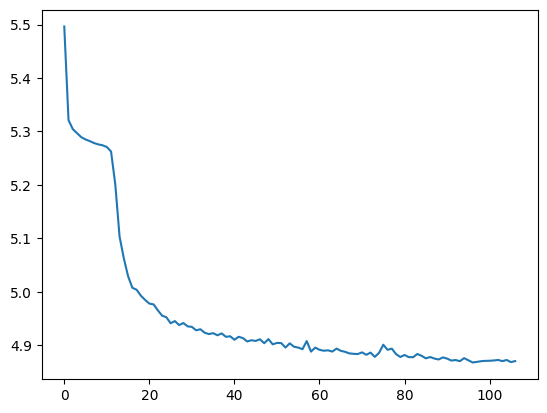

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(train_loss_list)